(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
===============is null sum===========
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome         

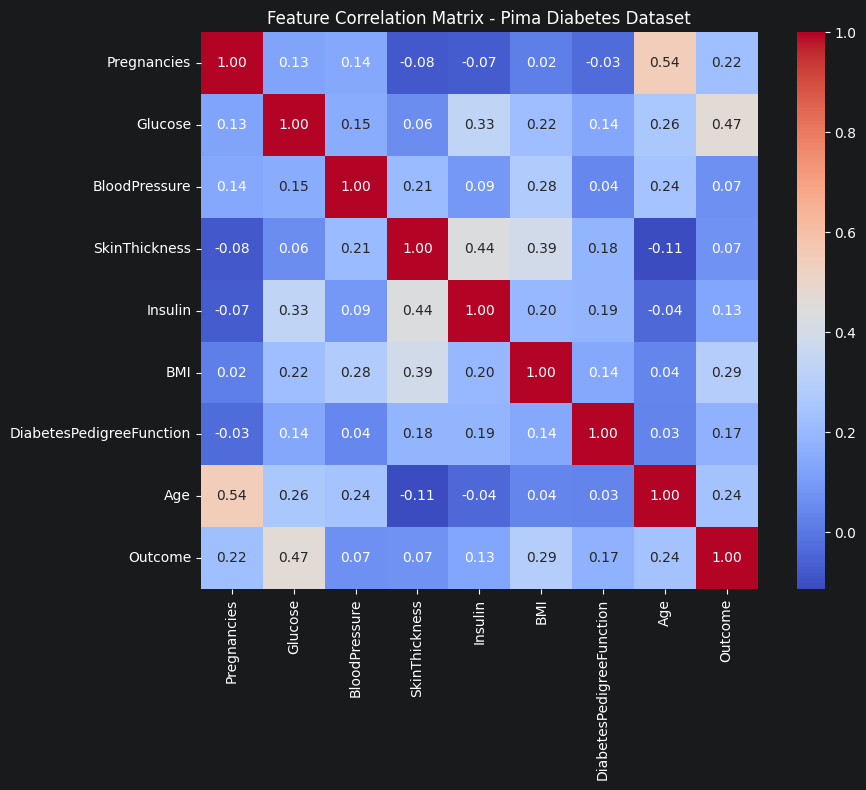

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetes.csv")

# Basic sanity check
print(df.shape)
print(df.head())
print("===============is null sum===========")
print(df.isnull().sum())  # Pima dataset often has 0s standing in for missing values
print("=====================================")

# Correlation matrix
corr = df.corr()
print(corr["Outcome"].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix - Pima Diabetes Dataset")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


In [3]:
import pandas as pd
import numpy as np
import pennylane as qml
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import time

# ---------------------------
# 1. Load and clean data
# ---------------------------
df = pd.read_csv("diabetes.csv")

cols_with_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_invalid_zero] = df[cols_with_invalid_zero].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

# ---------------------------
# 2. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Scale + PCA down to n_qubits
# ---------------------------
n_qubits = 6  # keep low for simulator speed

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=n_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance with {n_qubits} components: {pca.explained_variance_ratio_.sum():.3f}")

# Scale PCA output to [0, pi] for angle encoding
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_q = angle_scaler.fit_transform(X_train_pca)
X_test_q = angle_scaler.transform(X_test_pca)

X_train_t = torch.tensor(X_train_q, dtype=torch.float32)
X_test_t = torch.tensor(X_test_q, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ---------------------------
# 4. Quantum circuit (VQC/QNN)
# ---------------------------
n_layers = 5
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits)}
qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qlayer
        self.classical_out = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.qlayer(x)
        x = self.classical_out(x)
        return torch.sigmoid(x)

model = HybridModel()

# ---------------------------
# 5. Train the hybrid model
# ---------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

epochs = 30
batch_size = 32

start_time = time.time()

for epoch in range(epochs):
    permutation = torch.randperm(X_train_t.size(0))
    epoch_loss = 0.0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        preds = model(batch_x)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

quantum_train_time = time.time() - start_time

# ---------------------------
# 6. Evaluate hybrid model
# ---------------------------
model.eval()
with torch.no_grad():
    y_prob_q = model(X_test_t).squeeze().numpy()
y_pred_q = (y_prob_q >= 0.5).astype(int)

def get_metrics(y_true, y_pred, y_prob, model_name, train_time):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)  # recall
    specificity = tn / (tn + fp)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Train Time (s)": train_time
    }

results = []
results.append(get_metrics(y_test, y_pred_q, y_prob_q, "Hybrid QNN", quantum_train_time))

# ---------------------------
# 7. Classical baselines
# ---------------------------
start_time = time.time()
svm = SVC(probability=True, kernel="rbf")
svm.fit(X_train_scaled, y_train)
svm_time = time.time() - start_time
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
y_pred_svm = svm.predict(X_test_scaled)
results.append(get_metrics(y_test, y_pred_svm, y_prob_svm, "SVM (classical)", svm_time))

start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_time = time.time() - start_time
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = rf.predict(X_test_scaled)
results.append(get_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest (classical)", rf_time))

# ---------------------------
# 8. Results table
# ---------------------------
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print(results_df.to_string(index=False))
print("="*70)

Explained variance with 6 components: 0.894
Epoch 5/30 - Loss: 9.7079
Epoch 10/30 - Loss: 9.5033
Epoch 15/30 - Loss: 9.5607
Epoch 20/30 - Loss: 9.5699
Epoch 25/30 - Loss: 9.7009
Epoch 30/30 - Loss: 10.1382

                    Model  Accuracy  Sensitivity  Specificity       F1      AUC  Train Time (s)
               Hybrid QNN  0.688312     0.388889         0.85 0.466667 0.764815       50.320234
          SVM (classical)  0.740260     0.555556         0.84 0.600000 0.796296        0.024278
Random Forest (classical)  0.779221     0.611111         0.87 0.660000 0.817870        0.081374


In [4]:
import pandas as pd
import numpy as np
import pennylane as qml
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import time

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------
# 1. Load and clean data
# ---------------------------
df = pd.read_csv("diabetes.csv")

cols_with_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_invalid_zero] = df[cols_with_invalid_zero].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

# ---------------------------
# 2. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Scale + PCA down to n_qubits
# ---------------------------
n_qubits = 6

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=n_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance with {n_qubits} components: {pca.explained_variance_ratio_.sum():.3f}")

angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_q = angle_scaler.fit_transform(X_train_pca)
X_test_q = angle_scaler.transform(X_test_pca)

X_train_t = torch.tensor(X_train_q, dtype=torch.float32)
X_test_t = torch.tensor(X_test_q, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ---------------------------
# 4. Quantum circuit — StronglyEntanglingLayers, 3 layers
# ---------------------------
n_layers = 3
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# StronglyEntanglingLayers needs shape (n_layers, n_qubits, 3) — 3 rotation angles (X,Y,Z) per qubit per layer
weight_shapes = {"weights": (n_layers, n_qubits, 3)}
qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qlayer
        self.classical_out = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.qlayer(x)
        x = self.classical_out(x)
        return torch.sigmoid(x)

model = HybridModel()

# ---------------------------
# 5. Train the hybrid model
# ---------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

epochs = 30
batch_size = 32

start_time = time.time()

for epoch in range(epochs):
    permutation = torch.randperm(X_train_t.size(0))
    epoch_loss = 0.0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        preds = model(batch_x)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

quantum_train_time = time.time() - start_time

# ---------------------------
# 6. Evaluate hybrid model
# ---------------------------
model.eval()
with torch.no_grad():
    y_prob_q = model(X_test_t).squeeze().numpy()
y_pred_q = (y_prob_q >= 0.5).astype(int)

def get_metrics(y_true, y_pred, y_prob, model_name, train_time):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Train Time (s)": train_time
    }

results = []
results.append(get_metrics(y_test, y_pred_q, y_prob_q, "Hybrid QNN (StronglyEntangling)", quantum_train_time))

# ---------------------------
# 7. Classical baselines (unchanged, for comparison)
# ---------------------------
start_time = time.time()
svm = SVC(probability=True, kernel="rbf")
svm.fit(X_train_scaled, y_train)
svm_time = time.time() - start_time
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
y_pred_svm = svm.predict(X_test_scaled)
results.append(get_metrics(y_test, y_pred_svm, y_prob_svm, "SVM (classical)", svm_time))

start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_time = time.time() - start_time
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = rf.predict(X_test_scaled)
results.append(get_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest (classical)", rf_time))

# ---------------------------
# 8. Results table
# ---------------------------
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print(results_df.to_string(index=False))
print("="*70)

Explained variance with 6 components: 0.894
Epoch 5/30 - Loss: 9.7047
Epoch 10/30 - Loss: 9.6780
Epoch 15/30 - Loss: 9.6960
Epoch 20/30 - Loss: 9.3436
Epoch 25/30 - Loss: 9.2017
Epoch 30/30 - Loss: 9.5792

                          Model  Accuracy  Sensitivity  Specificity       F1      AUC  Train Time (s)
Hybrid QNN (StronglyEntangling)  0.727273     0.481481         0.86 0.553191 0.797037       69.666869
                SVM (classical)  0.740260     0.555556         0.84 0.600000 0.796389        0.021961
      Random Forest (classical)  0.779221     0.611111         0.87 0.660000 0.817870        0.076245


In [5]:
import pandas as pd
import numpy as np
import pennylane as qml
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import time

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------
# 1. Load and clean data
# ---------------------------
df = pd.read_csv("diabetes.csv")

cols_with_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_invalid_zero] = df[cols_with_invalid_zero].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

# ---------------------------
# 2. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Scale + PCA down to n_qubits
# ---------------------------
n_qubits = 8

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=n_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance with {n_qubits} components: {pca.explained_variance_ratio_.sum():.3f}")

angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_q = angle_scaler.fit_transform(X_train_pca)
X_test_q = angle_scaler.transform(X_test_pca)

X_train_t = torch.tensor(X_train_q, dtype=torch.float32)
X_test_t = torch.tensor(X_test_q, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ---------------------------
# 4. Quantum circuit — StronglyEntanglingLayers, 3 layers
# ---------------------------
n_layers = 3
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# StronglyEntanglingLayers needs shape (n_layers, n_qubits, 3) — 3 rotation angles (X,Y,Z) per qubit per layer
weight_shapes = {"weights": (n_layers, n_qubits, 3)}
qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qlayer
        self.classical_out = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.qlayer(x)
        x = self.classical_out(x)
        return torch.sigmoid(x)

model = HybridModel()

# ---------------------------
# 5. Train the hybrid model
# ---------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

epochs = 30
batch_size = 32

start_time = time.time()

for epoch in range(epochs):
    permutation = torch.randperm(X_train_t.size(0))
    epoch_loss = 0.0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        preds = model(batch_x)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

quantum_train_time = time.time() - start_time

# ---------------------------
# 6. Evaluate hybrid model
# ---------------------------
model.eval()
with torch.no_grad():
    y_prob_q = model(X_test_t).squeeze().numpy()
y_pred_q = (y_prob_q >= 0.5).astype(int)

def get_metrics(y_true, y_pred, y_prob, model_name, train_time):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Train Time (s)": train_time
    }

results = []
results.append(get_metrics(y_test, y_pred_q, y_prob_q, "Hybrid QNN (StronglyEntangling)", quantum_train_time))

# ---------------------------
# 7. Classical baselines (unchanged, for comparison)
# ---------------------------
start_time = time.time()
svm = SVC(probability=True, kernel="rbf")
svm.fit(X_train_scaled, y_train)
svm_time = time.time() - start_time
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
y_pred_svm = svm.predict(X_test_scaled)
results.append(get_metrics(y_test, y_pred_svm, y_prob_svm, "SVM (classical)", svm_time))

start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_time = time.time() - start_time
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = rf.predict(X_test_scaled)
results.append(get_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest (classical)", rf_time))

# ---------------------------
# 8. Results table
# ---------------------------
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print(results_df.to_string(index=False))
print("="*70)

Explained variance with 8 components: 1.000
Epoch 5/30 - Loss: 9.5579
Epoch 10/30 - Loss: 9.1297
Epoch 15/30 - Loss: 9.0898
Epoch 20/30 - Loss: 8.9867
Epoch 25/30 - Loss: 8.9172
Epoch 30/30 - Loss: 9.4068

                          Model  Accuracy  Sensitivity  Specificity       F1      AUC  Train Time (s)
Hybrid QNN (StronglyEntangling)  0.733766     0.574074         0.82 0.601942 0.797037       99.211985
                SVM (classical)  0.740260     0.555556         0.84 0.600000 0.796389        0.021324
      Random Forest (classical)  0.779221     0.611111         0.87 0.660000 0.817870        0.079738
